<a href="https://www.kaggle.com/code/ionelaralucacrisan/music-and-mental-health-eda?scriptVersionId=301961820" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mxmh-survey-results/mxmh_survey_results.csv


# Introduction 

EDA - What is it - a process during which data gets into a shape that can be used for analysis
    
- How to do it - there are some steps that are common to (most probably) all EDA (checking for missing values for example) ... and a few others that depend highly on the dataset (how/where from to retreive the data)

... 

- Dataset - it is about music - behaviours related to music listening and mental health. I love music - I use it sometimes to express my feelings - and I've been interested in mental health all the way to my adult personal life and career path so, with great entusiasm I chose this dataset to apply EDA steps on it. 

# Retreive the data 

In [3]:
#libraries we need 

import pandas as pd 
import plotly.express as px
import datetime
import requests 
import json 
import seaborn as sns 

# Summary of the data 

In [3]:
#read the data
#look @ first 6 rows

MMH = pd.read_csv("/kaggle/input/mxmh-survey-results/mxmh_survey_results.csv")
MMH.head(6)

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
5,8/27/2022 21:56:50,18.0,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,...,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve,I understand.


In [4]:
#last 7 rows 

MMH.tail(7)

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
729,10/30/2022 13:13:32,21.0,I do not use a streaming service.,0.5,No,No,No,Pop,Yes,No,...,Sometimes,Sometimes,Very frequently,Never,6.0,2.0,2.0,0.0,Improve,I understand.
730,10/30/2022 13:15:26,21.0,Spotify,2.0,Yes,No,No,R&B,Yes,Yes,...,Very frequently,Sometimes,Sometimes,Sometimes,7.0,6.0,4.0,6.0,Improve,I understand.
731,10/30/2022 14:37:28,17.0,Spotify,2.0,Yes,Yes,No,Rock,Yes,Yes,...,Never,Rarely,Very frequently,Never,7.0,6.0,0.0,9.0,Improve,I understand.
732,11/1/2022 22:26:42,18.0,Spotify,1.0,Yes,Yes,No,Pop,Yes,Yes,...,Never,Never,Sometimes,Sometimes,3.0,2.0,2.0,5.0,Improve,I understand.
733,11/3/2022 23:24:38,19.0,Other streaming service,6.0,Yes,No,Yes,Rap,Yes,No,...,Sometimes,Sometimes,Rarely,Rarely,2.0,2.0,2.0,2.0,Improve,I understand.
734,11/4/2022 17:31:47,19.0,Spotify,5.0,Yes,Yes,No,Classical,No,No,...,Never,Never,Never,Sometimes,2.0,3.0,2.0,1.0,Improve,I understand.
735,11/9/2022 1:55:20,29.0,YouTube Music,2.0,Yes,No,No,Hip hop,Yes,Yes,...,Very frequently,Very frequently,Very frequently,Rarely,2.0,2.0,2.0,5.0,Improve,I understand.


In [5]:
# the number of entries 

MMH.shape

(736, 33)

In [6]:
# data types 

MMH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    object 
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    object 
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    object 
 5   Instrumentalist               732 non-null    object 
 6   Composer                      735 non-null    object 
 7   Fav genre                     736 non-null    object 
 8   Exploratory                   736 non-null    object 
 9   Foreign languages             732 non-null    object 
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    object 
 12  Frequency [Country]           736 non-null    object 
 13  Frequ

In [7]:
#names of the columns 

MMH.columns

Index(['Timestamp', 'Age', 'Primary streaming service', 'Hours per day',
       'While working', 'Instrumentalist', 'Composer', 'Fav genre',
       'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]',
       'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
       'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]',
       'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]',
       'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]',
       'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]',
       'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects',
       'Permissions'],
      dtype='object')

In [8]:
#rename the columns where needed - 

MMH.rename(columns={'Primary streaming service' : 'Streaming', 'Hours per day' : 'Nrofhours', 'While working' : 'Workingyesorno', 'Fav genre' : 'Fav', 'Foreign languages' : 'Foreignlng', 'Frequency [Classical]' : 'Classical', 'Frequency [Country]' : 'Country', 'Frequency [EDM]': 'EDM', 'Frequency [Folk]' : 'Folk', 'Frequency [Gospel]' : 'Gospel', 'Frequency [Hip hop]' : 'Hiphop' , 'Frequency [Jazz]' : 'Jazz', 'Frequency [K pop]' : 'Kpop', 'Frequency [Latin]' : 'Latin', 'Frequency [Lofi]' : 'Lofi', 'Frequency [Metal]' : 'Metal', 'Frequency [Pop]' : 'Pop', 'Frequency [R&B]' : 'RandB', 'Frequency [Rap]' : 'Rap', 'Frequency [Rock]' : 'Rock', 'Frequency [Video game music]' : 'VideoGameMus', 'Music effects': 'Effects' }, inplace=True)
MMH.head(3)

,Timestamp,Age,Streaming,Nrofhours,Workingyesorno,Instrumentalist,Composer,Fav,Exploratory,Foreignlng,...,RandB,Rap,Rock,VideoGameMus,Anxiety,Depression,Insomnia,OCD,Effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.


In [9]:
#names of the columns  - after renaming it 

MMH.columns

Index(['Timestamp', 'Age', 'Streaming', 'Nrofhours', 'Workingyesorno',
       'Instrumentalist', 'Composer', 'Fav', 'Exploratory', 'Foreignlng',
       'BPM', 'Classical', 'Country', 'EDM', 'Folk', 'Gospel', 'Hiphop',
       'Jazz', 'Kpop', 'Latin', 'Lofi', 'Metal', 'Pop', 'RandB', 'Rap', 'Rock',
       'VideoGameMus', 'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Effects',
       'Permissions'],
      dtype='object')

# Deal with missing data

In [10]:
#check for missing values 

#it seems it is ok with or without print

MMH.isnull().sum()

Timestamp            0
Age                  1
Streaming            1
Nrofhours            0
Workingyesorno       3
Instrumentalist      4
Composer             1
Fav                  0
Exploratory          0
Foreignlng           4
BPM                107
Classical            0
Country              0
EDM                  0
Folk                 0
Gospel               0
Hiphop               0
Jazz                 0
Kpop                 0
Latin                0
Lofi                 0
Metal                0
Pop                  0
RandB                0
Rap                  0
Rock                 0
VideoGameMus         0
Anxiety              0
Depression           0
Insomnia             0
OCD                  0
Effects              8
Permissions          0
dtype: int64

In [11]:
print(MMH.isnull().sum())

# statistics of missing values 

Timestamp            0
Age                  1
Streaming            1
Nrofhours            0
Workingyesorno       3
Instrumentalist      4
Composer             1
Fav                  0
Exploratory          0
Foreignlng           4
BPM                107
Classical            0
Country              0
EDM                  0
Folk                 0
Gospel               0
Hiphop               0
Jazz                 0
Kpop                 0
Latin                0
Lofi                 0
Metal                0
Pop                  0
RandB                0
Rap                  0
Rock                 0
VideoGameMus         0
Anxiety              0
Depression           0
Insomnia             0
OCD                  0
Effects              8
Permissions          0
dtype: int64


In [12]:
#we noticed that, by far, most most missing values are at BPM, I considered for a second dropping the variable instead of missing values, but I thing it is important to consider the rythm, the pace so I will keep it 

MMH = MMH.dropna()    # Dropping the missing values.

MMH.count()

Timestamp          616
Age                616
Streaming          616
Nrofhours          616
Workingyesorno     616
Instrumentalist    616
Composer           616
Fav                616
Exploratory        616
Foreignlng         616
BPM                616
Classical          616
Country            616
EDM                616
Folk               616
Gospel             616
Hiphop             616
Jazz               616
Kpop               616
Latin              616
Lofi               616
Metal              616
Pop                616
RandB              616
Rap                616
Rock               616
VideoGameMus       616
Anxiety            616
Depression         616
Insomnia           616
OCD                616
Effects            616
Permissions        616
dtype: int64

In [13]:
print(MMH.isnull().sum())

# statistics of missing values after dropping NA

Timestamp          0
Age                0
Streaming          0
Nrofhours          0
Workingyesorno     0
Instrumentalist    0
Composer           0
Fav                0
Exploratory        0
Foreignlng         0
BPM                0
Classical          0
Country            0
EDM                0
Folk               0
Gospel             0
Hiphop             0
Jazz               0
Kpop               0
Latin              0
Lofi               0
Metal              0
Pop                0
RandB              0
Rap                0
Rock               0
VideoGameMus       0
Anxiety            0
Depression         0
Insomnia           0
OCD                0
Effects            0
Permissions        0
dtype: int64


# Deal with duplicates 

In [14]:
#check the number of entries after dropping NA

MMH.shape

(616, 33)

In [15]:
duplicate_rows_MMH = MMH[MMH.duplicated()]

print("number of duplicate rows: ", duplicate_rows_MMH.shape)

number of duplicate rows:  (0, 33)


# Drop unnecesary columns

In [16]:
# drop the permissions column

MMH = MMH.drop(['Permissions'], axis =1)

MMH.head(7)

,Timestamp,Age,Streaming,Nrofhours,Workingyesorno,Instrumentalist,Composer,Fav,Exploratory,Foreignlng,...,Pop,RandB,Rap,Rock,VideoGameMus,Anxiety,Depression,Insomnia,OCD,Effects
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve
5,8/27/2022 21:56:50,18.0,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,...,Very frequently,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve
6,8/27/2022 22:00:29,18.0,YouTube Music,3.0,Yes,Yes,No,Video game music,Yes,Yes,...,Rarely,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve
7,8/27/2022 22:18:59,21.0,Spotify,1.0,Yes,No,No,K pop,Yes,Yes,...,Sometimes,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,Improve
8,8/27/2022 22:33:05,19.0,Spotify,6.0,Yes,No,No,Rock,No,No,...,Never,Never,Never,Very frequently,Never,2.0,0.0,0.0,0.0,Improve


# Detecting outliers

<Axes: xlabel='Age'>

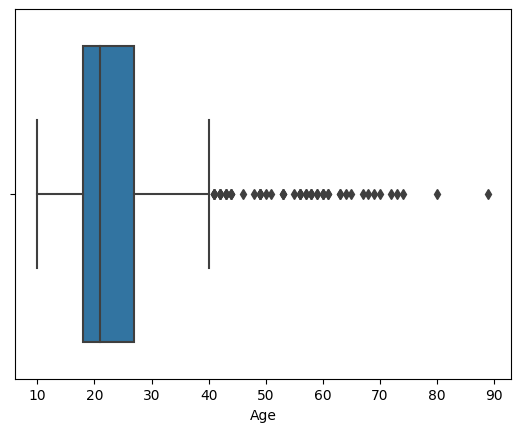

In [17]:
#check out if there are outliers in the age of the respondents 

sns.boxplot(x=MMH['Age']) 

# most of the respondents are aged between 17 and 25 years old, with just a few being over 70, we'll keep that as it is 

In [1]:
#check out if there are outliers in the number of hours 

sns.boxplot(x=MMH['Nrofhours']) 

#there is one answer ??? - 24 hours a day - it is not possible on not ok so...  remove it ?!? 

NameError: name 'sns' is not defined